# HR Workforce Analytics & Employee Performance Dashboard

## Project Overview

This project analyzes employee data to understand workforce trends, employee performance, productivity, salary, attendance, and attrition.
The goal is to generate actionable insights that can support better HR decision-making, workforce planning, and employee retention. 
The analysis also identifies key factors affecting employee performance and turnover to help organizations develop effective HR strategies.

## Dataset Overview

The dataset contains 10,050 employee records and 29 features covering employee demographics, workforce structure, employment history, salary, performance, attendance, engagement, and attrition.

It provides a comprehensive foundation for analyzing workforce trends, employee performance, productivity, and employee turnover.

## 1. Data Cleaning

The dataset is cleaned and prepared to ensure data quality and consistency before performing exploratory data analysis and statistical analysis.

The cleaning process includes checking the dataset structure, data types, missing values, duplicate records, date formats, categorical values, and numerical data consistency.

### 1.1 Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Load Dataset

In [2]:
df = pd.read_csv("HR_Workforce_Analytics_Raw_Data.csv")

### 1.3 Check Dataset Structure

In [3]:
df.shape

(10050, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            10050 non-null  object 
 1   Employee_Name          10050 non-null  object 
 2   Gender                 10050 non-null  object 
 3   Age                    10050 non-null  int64  
 4   Department             10050 non-null  object 
 5   Job_Role               10050 non-null  object 
 6   Location               10050 non-null  object 
 7   Employment_Type        10050 non-null  object 
 8   Joining_Date           10050 non-null  object 
 9   Exit_Date              9850 non-null   object 
 10  Years_at_Company       10050 non-null  float64
 11  Total_Work_Experience  10050 non-null  float64
 12  Education_Level        9870 non-null   object 
 13  Salary                 10050 non-null  int64  
 14  Performance_Rating     10050 non-null  int64  
 15  Jo

In [5]:
df.head()

,Employee_ID,Employee_Name,Gender,Age,Department,Job_Role,Location,Employment_Type,Joining_Date,Exit_Date,...,Attendance_Percentage,Projects_Completed,Training_Hours,Promotions,Sick_Days,Manager_Rating,Employee_Engagement,Attrition,Attrition_Reason,Remote_Work
0,EMP00001,Employee_00001,Male,39,Finance,Senior Accountant,Mumbai,Full-Time,11/14/2015,11/14/2016,...,96.9,6,24.0,5,3,3.0,3,No,Not Applicable,Yes
1,EMP00002,Employee_00002,Female,29,Sales,Business Development Executive,Kolkata,Contract,1/16/2018,4/16/2020,...,98.5,1,27.0,5,10,2.0,3,No,Not Applicable,Yes
2,EMP00003,Employee_00003,Female,22,IT,Software Engineer,Bengaluru,Full-Time,9/1/2014,3/1/2018,...,99.4,3,30.0,2,4,3.0,4,No,Not Applicable,Yes
3,EMP00004,Employee_00004,Female,22,Finance,Finance Manager,Kolkata,Full-Time,2/17/2017,11/17/2021,...,93.8,7,29.0,1,8,5.0,4,No,Not Applicable,Yes
4,EMP00005,Employee_00005,Female,37,Sales,Business Development Executive,Ahmedabad,Part-Time,2/26/2023,7/31/2026,...,96.1,6,38.0,1,3,3.0,2,No,Not Applicable,Yes


In [6]:
df.describe()

,Age,Years_at_Company,Total_Work_Experience,Salary,Performance_Rating,Job_Satisfaction,Work_Life_Balance,Monthly_Hours,Overtime_Hours,Attendance_Percentage,Projects_Completed,Training_Hours,Promotions,Sick_Days,Manager_Rating,Employee_Engagement
count,10050.000000,10050.000000,10050.000000,1.005000e+04,10050.000000,9929.000000,10050.000000,10050.000000,10050.000000,9929.000000,10050.000000,9930.000000,10050.000000,10050.000000,9970.000000,10050.000000
mean,31.661692,6.631035,9.470617,1.393410e+06,3.514826,3.389667,3.406667,170.906667,13.754030,94.323154,5.201194,34.978651,1.467463,5.069950,3.487362,3.436318
std,6.544046,3.470527,4.397560,3.179157e+05,0.962853,1.024842,0.999600,22.994248,10.036573,2.959586,2.409992,13.255865,1.401343,2.383265,1.108377,0.839832
min,21.000000,0.600000,0.500000,3.260330e+05,1.000000,1.000000,1.000000,110.000000,0.000000,83.500000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,27.000000,3.600000,6.300000,1.172148e+06,3.000000,3.000000,3.000000,155.000000,6.000000,92.300000,3.000000,26.000000,0.000000,3.000000,3.000000,3.000000
50%,31.000000,6.700000,9.500000,1.390212e+06,4.000000,3.000000,3.000000,171.000000,13.000000,94.400000,5.000000,35.000000,1.000000,5.000000,4.000000,3.000000
75%,36.000000,9.600000,12.700000,1.608811e+06,4.000000,4.000000,4.000000,186.000000,20.000000,96.400000,7.000000,44.000000,2.000000,7.000000,4.000000,4.000000
max,58.000000,12.600000,22.000000,2.506714e+06,5.000000,5.000000,5.000000,240.000000,65.000000,100.000000,16.000000,91.000000,6.000000,19.000000,5.000000,5.000000


### 1.4 Check Duplicate Records

In [7]:
df.duplicated().sum()

np.int64(3)

In [8]:
df["Employee_ID"].duplicated().sum()

np.int64(50)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

### 1.5 Check Missing Values

In [11]:
df.isnull().sum()

Employee_ID                0
Employee_Name              0
Gender                     0
Age                        0
Department                 0
Job_Role                   0
Location                   0
Employment_Type            0
Joining_Date               0
Exit_Date                198
Years_at_Company           0
Total_Work_Experience      0
Education_Level          180
Salary                     0
Performance_Rating         0
Job_Satisfaction         121
Work_Life_Balance          0
Monthly_Hours              0
Overtime_Hours             0
Attendance_Percentage    121
Projects_Completed         0
Training_Hours           120
Promotions                 0
Sick_Days                  0
Manager_Rating            80
Employee_Engagement        0
Attrition                  0
Attrition_Reason           0
Remote_Work                0
dtype: int64

### 1.6 Handle Missing Values

In [12]:
df["Education_Level"] = df["Education_Level"].fillna(
    df["Education_Level"].mode()[0]
)

In [13]:
num_cols = [
    "Job_Satisfaction",
    "Attendance_Percentage",
    "Training_Hours",
    "Manager_Rating"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

### 1.7 Coverting into Datetime

In [14]:
df["Exit_Date"] = pd.to_datetime(
    df["Exit_Date"],
    errors="coerce"
)

### 1.8 Check Date Conversion

In [15]:
df["Joining_Date"] = pd.to_datetime(
    df["Joining_Date"],
    errors="coerce"
)

In [16]:
df[["Joining_Date", "Exit_Date"]].dtypes

Joining_Date    datetime64[ns]
Exit_Date       datetime64[ns]
dtype: object

### 1.9 Check Categorical Values

In [17]:
categorical_cols = [
    "Gender",
    "Department",
    "Job_Role",
    "Location",
    "Employment_Type",
    "Education_Level",
    "Attrition",
    "Attrition_Reason",
    "Remote_Work"
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].unique())


 Gender
['Male' 'Female' 'Non-Binary']

 Department
['Finance' 'Sales' 'IT' 'Marketing' 'Operations' 'HR']

 Job_Role
['Senior Accountant' 'Business Development Executive' 'Software Engineer'
 'Finance Manager' 'Sales Manager' 'Sales Executive' 'QA Engineer'
 'Marketing Executive' 'System Administrator' 'Account Manager'
 'Marketing Manager' 'Operations Analyst' 'Sales Analyst' 'Recruiter'
 'Digital Marketing Specialist' 'Supply Chain Analyst' 'IT Manager'
 'Operations Manager' 'Data Analyst' 'HR Analyst' 'Accountant'
 'Financial Analyst' 'Operations Executive'
 'Talent Acquisition Specialist' 'DevOps Engineer' 'HR Executive'
 'Process Associate' 'Auditor' 'SEO Specialist' 'HR Manager'
 'Marketing Analyst']

 Location
['Mumbai' 'Kolkata' 'Bengaluru' 'Ahmedabad' 'Hyderabad' 'Pune' 'Chennai'
 'Delhi']

 Employment_Type
['Full-Time' 'Contract' 'Part-Time']

 Education_Level
["Master's" "Bachelor's" 'MBA' 'Diploma' 'PhD']

 Attrition
['No' 'Yes']

 Attrition_Reason
['Not Applicable' 'Work

### 1.10 Check Numerical Values

In [18]:
df[[
    "Age",
    "Salary",
    "Performance_Rating",
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Monthly_Hours",
    "Overtime_Hours",
    "Attendance_Percentage",
    "Projects_Completed",
    "Training_Hours",
    "Promotions",
    "Sick_Days",
    "Manager_Rating",
    "Employee_Engagement"
]].describe()

,Age,Salary,Performance_Rating,Job_Satisfaction,Work_Life_Balance,Monthly_Hours,Overtime_Hours,Attendance_Percentage,Projects_Completed,Training_Hours,Promotions,Sick_Days,Manager_Rating,Employee_Engagement
count,10047.000000,1.004700e+04,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000
mean,31.658704,1.393347e+06,3.514880,3.384891,3.406888,170.912511,13.756246,94.323838,5.201354,34.980492,1.467403,5.069673,3.491291,3.436449
std,6.542170,3.179351e+05,0.962957,1.019647,0.999435,22.991927,10.036892,2.941509,2.410155,13.177898,1.401383,2.383190,1.105026,0.839805
min,21.000000,3.260330e+05,1.000000,1.000000,1.000000,110.000000,0.000000,83.500000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,27.000000,1.172102e+06,3.000000,3.000000,3.000000,155.000000,6.000000,92.300000,3.000000,26.000000,0.000000,3.000000,3.000000,3.000000
50%,31.000000,1.390144e+06,4.000000,3.000000,3.000000,171.000000,13.000000,94.400000,5.000000,35.000000,1.000000,5.000000,4.000000,3.000000
75%,36.000000,1.608634e+06,4.000000,4.000000,4.000000,186.000000,20.000000,96.400000,7.000000,44.000000,2.000000,7.000000,4.000000,4.000000
max,58.000000,2.506714e+06,5.000000,5.000000,5.000000,240.000000,65.000000,100.000000,16.000000,91.000000,6.000000,19.000000,5.000000,5.000000


### 1.11 Validate Attrition Data

In [19]:
df["Attrition"].value_counts()

Attrition
No     9619
Yes     428
Name: count, dtype: int64

In [20]:
df["Attrition_Reason"].value_counts(dropna=False)

Attrition_Reason
Not Applicable         9619
Better Opportunity       74
Work-Life Balance        70
Compensation             56
Career Growth            54
Job Dissatisfaction      52
Manager Issues           36
Relocation               34
Personal Reasons         28
Workload                 24
Name: count, dtype: int64

In [21]:
pd.crosstab(
    df["Attrition"],
    df["Exit_Date"].isna()
)

Exit_Date,False,True
Attrition,,
No,9421,198
Yes,428,0


### 1.15 Create Active Employee Flag

In [22]:
df["Active_Employee"] = np.where(
    df["Attrition"] == "No",
    1,
    0
)

In [23]:
df["Exited_Employee"] = np.where(
    df["Attrition"] == "Yes",
    1,
    0
)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df["Exit_Date"] = df["Exit_Date"].fillna("Currently Working")

In [26]:
df.isnull().sum()

Employee_ID              0
Employee_Name            0
Gender                   0
Age                      0
Department               0
Job_Role                 0
Location                 0
Employment_Type          0
Joining_Date             0
Exit_Date                0
Years_at_Company         0
Total_Work_Experience    0
Education_Level          0
Salary                   0
Performance_Rating       0
Job_Satisfaction         0
Work_Life_Balance        0
Monthly_Hours            0
Overtime_Hours           0
Attendance_Percentage    0
Projects_Completed       0
Training_Hours           0
Promotions               0
Sick_Days                0
Manager_Rating           0
Employee_Engagement      0
Attrition                0
Attrition_Reason         0
Remote_Work              0
Active_Employee          0
Exited_Employee          0
dtype: int64

### 1.16 Save the Cleaned Dataset

In [27]:
output_file = "HR_Workforce_Analytics_Cleaned.csv"
df.to_csv(output_file, index=False)
print("Cleaned dataset saved successfully!")
print("File location:", output_file)

Cleaned dataset saved successfully!
File location: HR_Workforce_Analytics_Cleaned.csv


# 2.Workforce Analytics
Objective:

Analyze the overall workforce structure and understand employee distribution.

### 2.1 Total Employee Count

In [28]:
total_employees = df["Employee_ID"].count()

print("Total Employees:", total_employees)

Total Employees: 10047


### 2.2 Active and Exited Employee Analysis

In [29]:
active_employees = (df["Attrition"] == "No").sum()

exited_employees = (df["Attrition"] == "Yes").sum()

print("Active Employees:", active_employees)
print("Exited Employees:", exited_employees)

Active Employees: 9619
Exited Employees: 428


### 2.3 Department-wise Workforce Distribution

In [30]:
df["Department"].value_counts()

Department
IT            2684
Sales         2042
Operations    1909
Finance       1230
Marketing     1201
HR             981
Name: count, dtype: int64

### 2.4 Job Role Distribution

In [31]:
df["Job_Role"].value_counts()

Job_Role
QA Engineer                       472
IT Manager                        457
Software Engineer                 456
System Administrator              439
Data Analyst                      433
Business Development Executive    428
DevOps Engineer                   427
Sales Manager                     422
Sales Analyst                     404
Sales Executive                   403
Operations Executive              399
Operations Manager                395
Account Manager                   385
Process Associate                 384
Operations Analyst                371
Supply Chain Analyst              360
Digital Marketing Specialist      267
Finance Manager                   262
Auditor                           260
Accountant                        258
Marketing Analyst                 241
SEO Specialist                    239
Marketing Executive               232
Financial Analyst                 228
Senior Accountant                 222
Marketing Manager                 222
HR 

### 2.5 Location-wise Workforce Distribution

In [32]:
df["Location"].value_counts()

Location
Chennai      1301
Pune         1283
Delhi        1275
Bengaluru    1261
Hyderabad    1249
Kolkata      1232
Mumbai       1231
Ahmedabad    1215
Name: count, dtype: int64

### 2.6 Employment Type Analysis

In [33]:
df["Employment_Type"].value_counts()

Employment_Type
Full-Time    8428
Contract     1110
Part-Time     509
Name: count, dtype: int64

### 2.7 Workforce Visualization
Department Distribution

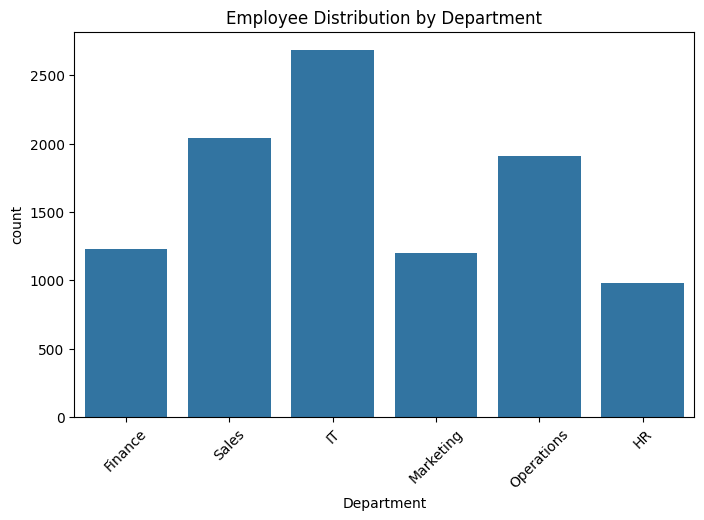

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    data=df
)

plt.title("Employee Distribution by Department")

plt.xticks(rotation=45)

plt.show()

# 3. Employee Data Analysis

## 3.1 Employee Performance Analysis
### Performance Rating Distribution

In [37]:
performance_distribution = df["Performance_Rating"].value_counts().sort_index()

print("Performance Rating Distribution:")
print(performance_distribution)

Performance Rating Distribution:
Performance_Rating
1     367
2     898
3    3381
4    3997
5    1404
Name: count, dtype: int64


### Average Performance Rating

In [38]:
average_performance = df["Performance_Rating"].mean()

print("Average Performance Rating:", round(average_performance, 2))

Average Performance Rating: 3.51


### Performance by Department

In [39]:
performance_by_department = (
    df.groupby("Department")["Performance_Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Performance by Department:")
print(performance_by_department)

Average Performance by Department:
Department
IT            3.523472
Marketing     3.517069
HR            3.514781
Sales         3.512243
Finance       3.508943
Operations    3.508119
Name: Performance_Rating, dtype: float64


### Visualization

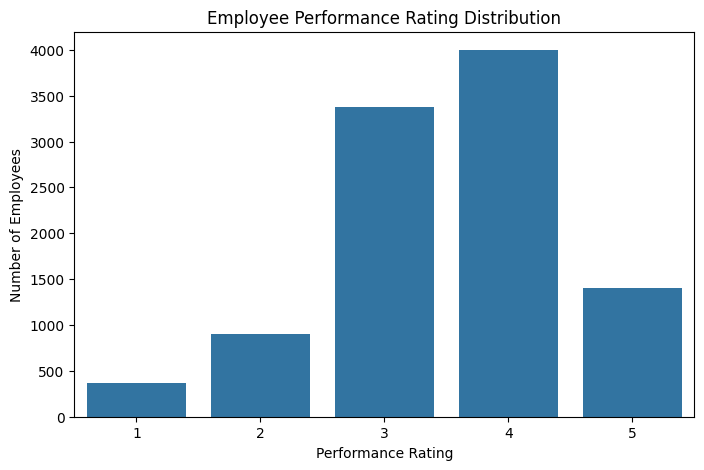

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Performance_Rating",
    data=df
)

plt.title("Employee Performance Rating Distribution")
plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")

plt.show()

## 3.2 Attrition Trend Analysis

### Attrition Distribution

In [41]:
attrition_distribution = df["Attrition"].value_counts()

print("Attrition Distribution:")
print(attrition_distribution)

Attrition Distribution:
Attrition
No     9619
Yes     428
Name: count, dtype: int64


### Attrition by Department

In [42]:
attrition_by_department = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

print("Attrition by Department:")
print(attrition_by_department)

Attrition by Department:
Attrition     No  Yes
Department           
Finance     1169   61
HR           936   45
IT          2579  105
Marketing   1154   47
Operations  1833   76
Sales       1948   94


### Attrition by Job Role

In [43]:
attrition_by_role = pd.crosstab(
    df["Job_Role"],
    df["Attrition"]
)

print("Attrition by Job Role:")
print(attrition_by_role)

Attrition by Job Role:
Attrition                        No  Yes
Job_Role                                
Account Manager                 365   20
Accountant                      245   13
Auditor                         249   11
Business Development Executive  411   17
Data Analyst                    411   22
DevOps Engineer                 415   12
Digital Marketing Specialist    255   12
Finance Manager                 249   13
Financial Analyst               218   10
HR Analyst                      208    8
HR Executive                    194   11
HR Manager                      183   11
IT Manager                      440   17
Marketing Analyst               230   11
Marketing Executive             223    9
Marketing Manager               217    5
Operations Analyst              360   11
Operations Executive            387   12
Operations Manager              380   15
Process Associate               364   20
QA Engineer                     453   19
Recruiter                       18

### Attrition vs Job Satisfaction

In [44]:
satisfaction_by_attrition = (
    df.groupby("Attrition")["Job_Satisfaction"]
    .mean()
)

print("Average Job Satisfaction by Attrition:")
print(satisfaction_by_attrition)

Average Job Satisfaction by Attrition:
Attrition
No     3.423225
Yes    2.523364
Name: Job_Satisfaction, dtype: float64


### Attrition vs Overtime

In [45]:
overtime_by_attrition = (
    df.groupby("Attrition")["Overtime_Hours"]
    .mean()
)

print("Average Overtime Hours by Attrition:")
print(overtime_by_attrition)

Average Overtime Hours by Attrition:
Attrition
No     13.587379
Yes    17.551402
Name: Overtime_Hours, dtype: float64


### Visualization

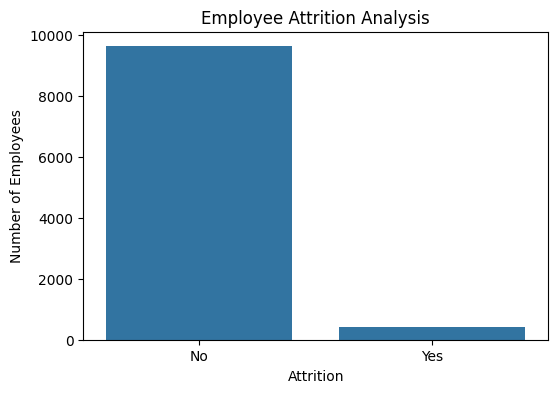

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df
)

plt.title("Employee Attrition Analysis")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

## 3.3 Department Analysis
### Employee Distribution by Department

In [47]:
department_distribution = df["Department"].value_counts()

print("Employee Distribution by Department:")
print(department_distribution)

Employee Distribution by Department:
Department
IT            2684
Sales         2042
Operations    1909
Finance       1230
Marketing     1201
HR             981
Name: count, dtype: int64


### Department-wise Average Salary

In [48]:
department_salary = (
    df.groupby("Department")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Salary by Department:")
print(department_salary)

Average Salary by Department:
Department
IT            1.555932e+06
Finance       1.448105e+06
Marketing     1.341668e+06
Sales         1.337172e+06
Operations    1.280940e+06
HR            1.278804e+06
Name: Salary, dtype: float64


### Department-wise Performance

In [49]:
department_performance = (
    df.groupby("Department")["Performance_Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Performance by Department:")
print(department_performance)

Average Performance by Department:
Department
IT            3.523472
Marketing     3.517069
HR            3.514781
Sales         3.512243
Finance       3.508943
Operations    3.508119
Name: Performance_Rating, dtype: float64


### Visualization

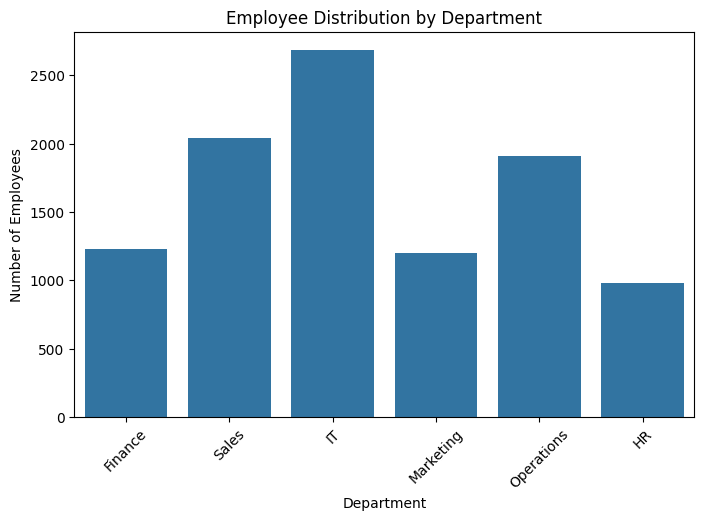

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    data=df
)

plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

plt.show()

## 3.4 Salary Distribution Analysis
### Salary Statistics

In [51]:
salary_statistics = df["Salary"].describe()

print("Salary Statistics:")
print(salary_statistics)

Salary Statistics:
count    1.004700e+04
mean     1.393347e+06
std      3.179351e+05
min      3.260330e+05
25%      1.172102e+06
50%      1.390144e+06
75%      1.608634e+06
max      2.506714e+06
Name: Salary, dtype: float64


### Average Salary by Department

In [53]:
average_salary_department = (
    df.groupby("Department")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Salary by Department:")
print(average_salary_department)

Average Salary by Department:
Department
IT            1.555932e+06
Finance       1.448105e+06
Marketing     1.341668e+06
Sales         1.337172e+06
Operations    1.280940e+06
HR            1.278804e+06
Name: Salary, dtype: float64


### Salary Distribution Visualization

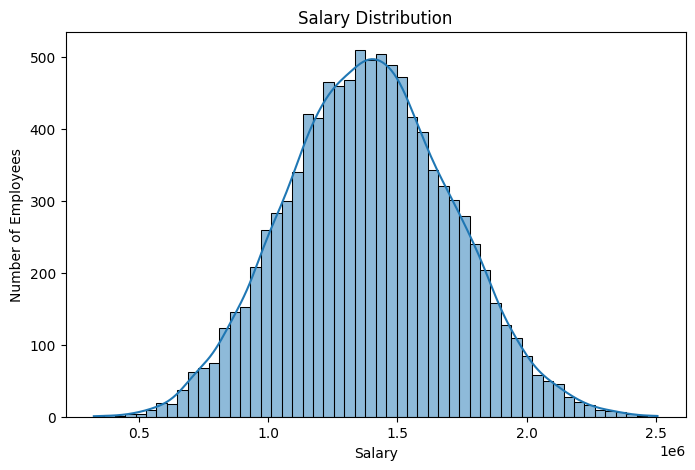

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Salary"],
    kde=True
)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

## 3.5 Attendance Pattern Analysis
### Average Attendance

In [55]:
average_attendance = df["Attendance_Percentage"].mean()

print(
    "Average Attendance:",
    round(average_attendance, 2),
    "%"
)

Average Attendance: 94.32 %


### Attendance by Attrition

In [56]:
attendance_by_attrition = (
    df.groupby("Attrition")["Attendance_Percentage"]
    .mean()
)

print("Average Attendance by Attrition:")
print(attendance_by_attrition)

Average Attendance by Attrition:
Attrition
No     94.334006
Yes    94.095327
Name: Attendance_Percentage, dtype: float64


### Attendance by Department

In [57]:
attendance_by_department = (
    df.groupby("Department")["Attendance_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Attendance by Department:")
print(attendance_by_department)

Average Attendance by Department:
Department
HR            94.440775
Operations    94.380199
IT            94.335358
Marketing     94.321149
Finance       94.296667
Sales         94.217777
Name: Attendance_Percentage, dtype: float64


### Visualization

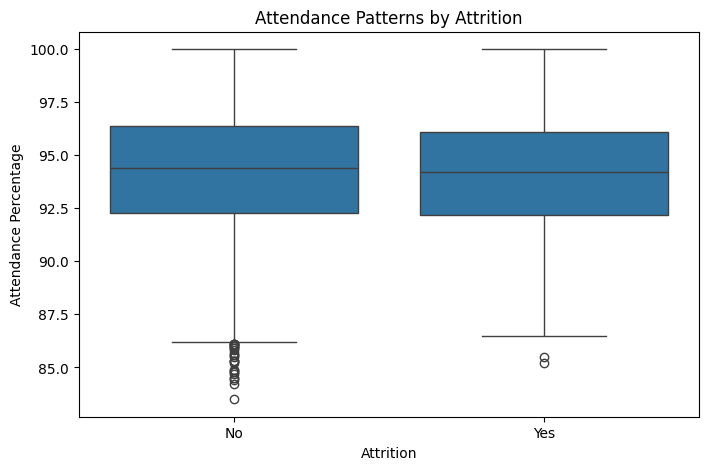

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="Attendance_Percentage",
    data=df
)

plt.title("Attendance Patterns by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Attendance Percentage")

plt.show()

# 4. HR KPI Calculation

## 4.1 Employee Retention Rate

In [59]:
total_employees = df["Employee_ID"].count()
active_employees = (df["Attrition"] == "No").sum()

retention_rate = (active_employees / total_employees) * 100

print("Employee Retention Rate:", round(retention_rate, 2), "%")

Employee Retention Rate: 95.74 %


## 4.2 Attrition Rate

In [60]:
exited_employees = (df["Attrition"] == "Yes").sum()

attrition_rate = (exited_employees / total_employees) * 100

print("Employee Attrition Rate:", round(attrition_rate, 2), "%")

Employee Attrition Rate: 4.26 %


## 4.3 Average Salary

In [61]:
average_salary = df["Salary"].mean()

print("Average Salary:", round(average_salary, 2))

Average Salary: 1393347.24


## 4.4 Performance Score

In [62]:
performance_score = df["Performance_Rating"].mean()

print("Overall Performance Score:", round(performance_score, 2))

Overall Performance Score: 3.51


## 4.5 Department Productivity

In [63]:
department_productivity = (
    df.groupby("Department")["Projects_Completed"]
    .mean()
    .sort_values(ascending=False)
)

print("Department Productivity:")
print(department_productivity)

Department Productivity:
Department
Marketing     5.253955
IT            5.226900
Finance       5.226829
Operations    5.196438
Sales         5.189030
HR            5.070336
Name: Projects_Completed, dtype: float64


## 4.6 KPI Summary

In [64]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Employee Retention Rate",
        "Employee Attrition Rate",
        "Average Salary",
        "Performance Score"
    ],
    "Value": [
        round(retention_rate, 2),
        round(attrition_rate, 2),
        round(average_salary, 2),
        round(performance_score, 2)
    ]
})

kpi_summary

,KPI,Value
0,Employee Retention Rate,95.74
1,Employee Attrition Rate,4.26
2,Average Salary,1393347.24
3,Performance Score,3.51


# 5. Factors Affecting Employee Turnover
To identify employee-related factors that may be associated with employee turnover by comparing active and exited employees across key HR attributes.

## 5.1 Select Relevant Factors

In [74]:
turnover_factors = [
    "Job_Satisfaction",
    "Overtime_Hours",
    "Salary",
    "Employee_Engagement",
    "Work_Life_Balance",
    "Years_at_Company",
    "Performance_Rating",
    "Attendance_Percentage"
]

## 5.2 Compare Factors by Attrition

In [75]:
factor_comparison = df.groupby("Attrition")[turnover_factors].mean()

factor_comparison

,Job_Satisfaction,Overtime_Hours,Salary,Employee_Engagement,Work_Life_Balance,Years_at_Company,Performance_Rating,Attendance_Percentage
Attrition,,,,,,,,
No,3.423225,13.587379,1.394687e+06,3.469903,3.428631,6.643986,3.529785,94.334006
Yes,2.523364,17.551402,1.363229e+06,2.684579,2.918224,6.324533,3.179907,94.095327


## 5.3 Calculate Differences

In [76]:
factor_difference = (
    factor_comparison.loc["Yes"] -
    factor_comparison.loc["No"]
)

factor_difference.sort_values()

Salary                  -31457.865445
Job_Satisfaction            -0.899860
Employee_Engagement         -0.785324
Work_Life_Balance           -0.510407
Performance_Rating          -0.349878
Years_at_Company            -0.319453
Attendance_Percentage       -0.238679
Overtime_Hours               3.964023
dtype: float64

## 5.4 Identify Key Turnover Factors

### Key Findings

The analysis identified Salary, Job Satisfaction, Employee Engagement, Overtime Hours, and Work-Life Balance as notable factors associated with employee turnover. Exited employees had lower average salary, job satisfaction, employee engagement, and work-life balance, while their average overtime hours were higher compared with active employees.

# 6. Statistical Analysis
To statistically evaluate the relationships and differences identified during the employee turnover analysis.

## 6.1 Descriptive Statistics

In [77]:
statistical_summary = df[[
    "Age",
    "Years_at_Company",
    "Total_Work_Experience",
    "Salary",
    "Performance_Rating",
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Monthly_Hours",
    "Overtime_Hours",
    "Attendance_Percentage",
    "Projects_Completed",
    "Training_Hours",
    "Employee_Engagement"
]].describe()

statistical_summary

,Age,Years_at_Company,Total_Work_Experience,Salary,Performance_Rating,Job_Satisfaction,Work_Life_Balance,Monthly_Hours,Overtime_Hours,Attendance_Percentage,Projects_Completed,Training_Hours,Employee_Engagement
count,10047.000000,10047.000000,10047.000000,1.004700e+04,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000,10047.000000
mean,31.658704,6.630377,9.470439,1.393347e+06,3.514880,3.384891,3.406888,170.912511,13.756246,94.323838,5.201354,34.980492,3.436449
std,6.542170,3.470413,4.397339,3.179351e+05,0.962957,1.019647,0.999435,22.991927,10.036892,2.941509,2.410155,13.177898,0.839805
min,21.000000,0.600000,0.500000,3.260330e+05,1.000000,1.000000,1.000000,110.000000,0.000000,83.500000,1.000000,0.000000,1.000000
25%,27.000000,3.600000,6.300000,1.172102e+06,3.000000,3.000000,3.000000,155.000000,6.000000,92.300000,3.000000,26.000000,3.000000
50%,31.000000,6.700000,9.500000,1.390144e+06,4.000000,3.000000,3.000000,171.000000,13.000000,94.400000,5.000000,35.000000,3.000000
75%,36.000000,9.600000,12.700000,1.608634e+06,4.000000,4.000000,4.000000,186.000000,20.000000,96.400000,7.000000,44.000000,4.000000
max,58.000000,12.600000,22.000000,2.506714e+06,5.000000,5.000000,5.000000,240.000000,65.000000,100.000000,16.000000,91.000000,5.000000


## 6.2 Correlation Analysis

In [78]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Age,Years_at_Company,Total_Work_Experience,Salary,Performance_Rating,Job_Satisfaction,Work_Life_Balance,Monthly_Hours,Overtime_Hours,Attendance_Percentage,Projects_Completed,Training_Hours,Promotions,Sick_Days,Manager_Rating,Employee_Engagement,Active_Employee,Exited_Employee
Age,1.000000,-0.006585,-0.006167,0.557648,0.014071,0.001370,0.014268,-0.010571,0.005018,0.010196,0.001897,-0.003263,0.001582,-0.016396,0.019547,0.011733,-0.006409,0.006409
Years_at_Company,-0.006585,1.000000,0.775860,0.513290,-0.003376,-0.004573,-0.013373,0.015440,0.010655,0.004466,0.002769,-0.009964,0.534151,0.002039,0.005068,-0.008464,0.018591,-0.018591
Total_Work_Experience,-0.006167,0.775860,1.000000,0.636604,-0.003060,0.003792,-0.010848,0.010227,0.016553,0.016430,-0.003012,-0.006056,0.418294,0.012768,0.002575,-0.004490,0.011169,-0.011169
Salary,0.557648,0.513290,0.636604,1.000000,0.234511,0.000375,0.009967,-0.010247,0.011623,0.021878,0.111644,0.043193,0.372601,-0.004734,0.196530,0.094414,0.019983,-0.019983
Performance_Rating,0.014071,-0.003376,-0.003060,0.234511,1.000000,-0.000207,0.005086,-0.007865,-0.001453,0.003907,0.466659,0.216768,-0.000802,0.001066,0.801932,0.383085,0.073381,-0.073381
Job_Satisfaction,0.001370,-0.004573,0.003792,0.000375,-0.000207,1.000000,0.004842,-0.027725,-0.021052,-0.009677,0.002607,-0.020695,-0.003584,-0.011569,-0.004667,0.401776,0.178237,-0.178237
Work_Life_Balance,0.014268,-0.013373,-0.010848,0.009967,0.005086,0.004842,1.000000,0.002156,0.003359,0.023924,-0.000419,0.009105,0.005064,0.002640,0.005643,0.406764,0.103142,-0.103142
Monthly_Hours,-0.010571,0.015440,0.010227,-0.010247,-0.007865,-0.027725,0.002156,1.000000,0.338940,-0.041146,-0.017615,-0.003434,0.014044,0.115164,-0.010097,-0.019154,-0.026012,0.026012
Overtime_Hours,0.005018,0.010655,0.016553,0.011623,-0.001453,-0.021052,0.003359,0.338940,1.000000,-0.132169,-0.008040,0.007893,0.034725,0.333550,-0.018074,-0.011244,-0.079764,0.079764
Attendance_Percentage,0.010196,0.004466,0.016430,0.021878,0.003907,-0.009677,0.023924,-0.041146,-0.132169,1.000000,-0.002574,-0.009953,0.010281,-0.032436,0.001336,0.006688,0.016388,-0.016388


### Correlation Heatmap

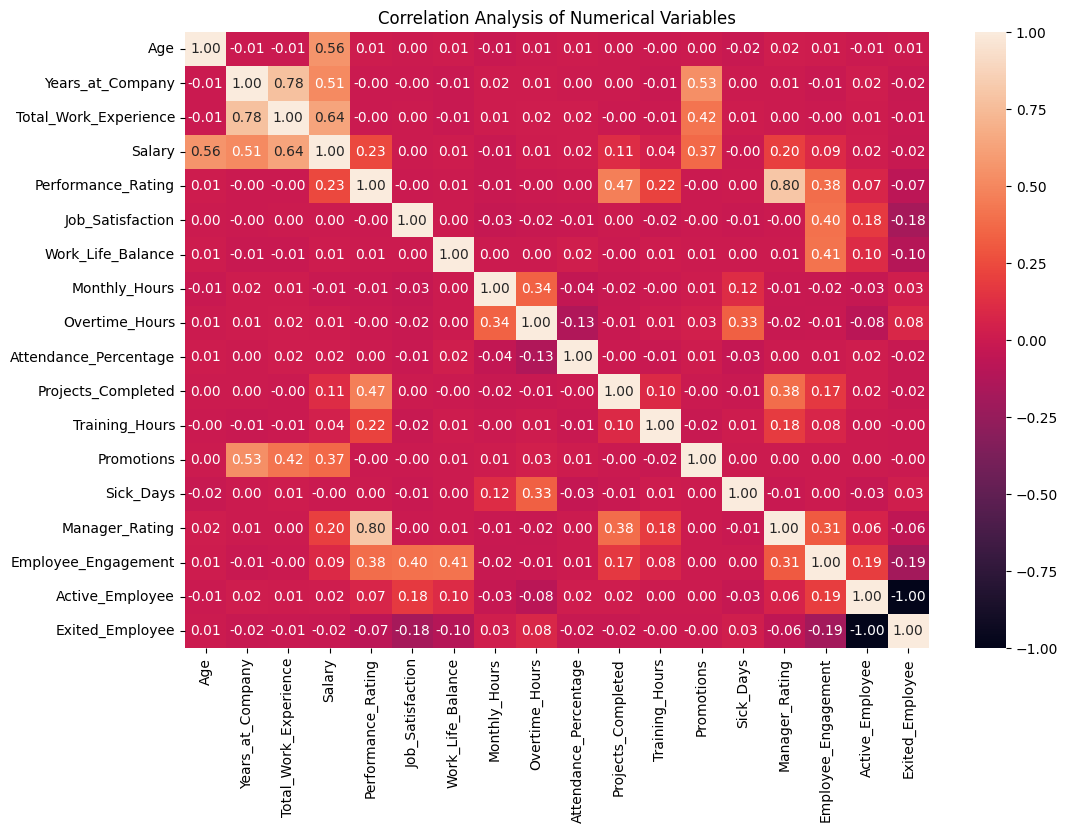

In [79]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Analysis of Numerical Variables")

plt.show()

## 6.3 Statistical Comparison: Active vs Exited Employees

In [80]:
turnover_comparison = df.groupby("Attrition")[
    [
        "Job_Satisfaction",
        "Overtime_Hours",
        "Salary",
        "Employee_Engagement",
        "Work_Life_Balance"
    ]
].mean()

turnover_comparison

,Job_Satisfaction,Overtime_Hours,Salary,Employee_Engagement,Work_Life_Balance
Attrition,,,,,
No,3.423225,13.587379,1.394687e+06,3.469903,3.428631
Yes,2.523364,17.551402,1.363229e+06,2.684579,2.918224


## 6.4 T-Test for Key Numerical Factors

In [82]:
from scipy.stats import ttest_ind

In [83]:
factors_to_test = [
    "Job_Satisfaction",
    "Overtime_Hours",
    "Salary",
    "Employee_Engagement",
    "Work_Life_Balance"
]

for factor in factors_to_test:
    active = df[df["Attrition"] == "No"][factor].dropna()
    exited = df[df["Attrition"] == "Yes"][factor].dropna()

    t_stat, p_value = ttest_ind(
        active,
        exited,
        equal_var=False
    )

    print(f"{factor}:")
    print("t-statistic:", round(t_stat, 3))
    print("p-value:", round(p_value, 4))
    print()

Job_Satisfaction:
t-statistic: 17.105
p-value: 0.0

Overtime_Hours:
t-statistic: -7.356
p-value: 0.0

Salary:
t-statistic: 1.959
p-value: 0.0507

Employee_Engagement:
t-statistic: 18.847
p-value: 0.0

Work_Life_Balance:
t-statistic: 9.731
p-value: 0.0



### Statistical Findings

An independent two-sample t-test was conducted to evaluate whether key employee factors differed significantly between active and exited employees.

The results showed statistically significant differences in Job Satisfaction, Overtime Hours, Employee Engagement, and Work-Life Balance (p < 0.05).

Salary did not show a statistically significant difference at the 5% significance level (p = 0.0507).

These results suggest that Job Satisfaction, Overtime Hours, Employee Engagement, and Work-Life Balance are statistically associated with employee turnover in this dataset.

# SQL Analysis

In [84]:
import sqlite3

### Create SQLite Database

In [85]:
conn = sqlite3.connect("hr_analytics.db")

In [87]:
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"], errors="coerce").dt.strftime("%Y-%m-%d")

df["Exit_Date"] = pd.to_datetime(df["Exit_Date"], errors="coerce").dt.strftime("%Y-%m-%d")

### For Database storing

In [88]:
df.to_sql(
    "employees",
    conn,
    if_exists="replace",
    index=False
)

10047

In [92]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables["name"].iloc[0])

employees


### Total Employee Count

In [100]:
query = """
SELECT COUNT(*) AS total_employees
FROM employees;
"""

result = pd.read_sql_query(query, conn)

result

,total_employees
0,10047


### Active and Exited Employees

In [101]:
query = """
SELECT 
    Attrition,
    COUNT(*) AS employee_count
FROM employees
GROUP BY Attrition;
"""

result = pd.read_sql_query(query, conn)

result

,Attrition,employee_count
0,No,9619
1,Yes,428


### Employee Count by Department

In [102]:
query = """
SELECT 
    Department,
    COUNT(*) AS employee_count
FROM employees
GROUP BY Department
ORDER BY employee_count DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Department,employee_count
0,IT,2684
1,Sales,2042
2,Operations,1909
3,Finance,1230
4,Marketing,1201
5,HR,981


### Average Salary by Department

In [104]:
query = """
SELECT 
    Department,
    ROUND(AVG(Salary), 2) AS average_salary
FROM employees
GROUP BY Department
ORDER BY average_salary DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Department,average_salary
0,IT,1555932.05
1,Finance,1448104.95
2,Marketing,1341667.62
3,Sales,1337171.92
4,Operations,1280940.13
5,HR,1278803.71


### Average Performance Rating by Department

In [105]:
query = """
SELECT 
    Department,
    ROUND(AVG(Performance_Rating), 2) AS average_performance
FROM employees
GROUP BY Department
ORDER BY average_performance DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Department,average_performance
0,Marketing,3.52
1,IT,3.52
2,Sales,3.51
3,Operations,3.51
4,HR,3.51
5,Finance,3.51


### Attrition by Department

In [106]:
query = """
SELECT 
    Department,
    Attrition,
    COUNT(*) AS employee_count
FROM employees
GROUP BY Department, Attrition
ORDER BY Department, Attrition;
"""

result = pd.read_sql_query(query, conn)

result

,Department,Attrition,employee_count
0,Finance,No,1169
1,Finance,Yes,61
2,HR,No,936
3,HR,Yes,45
4,IT,No,2579
5,IT,Yes,105
6,Marketing,No,1154
7,Marketing,Yes,47
8,Operations,No,1833
9,Operations,Yes,76


### Average Overtime Hours by Attrition

In [107]:
query = """
SELECT 
    Attrition,
    ROUND(AVG(Overtime_Hours), 2) AS average_overtime_hours
FROM employees
GROUP BY Attrition;
"""

result = pd.read_sql_query(query, conn)

result

,Attrition,average_overtime_hours
0,No,13.59
1,Yes,17.55


### Average Job Satisfaction by Attrition

In [108]:
query = """
SELECT 
    Attrition,
    ROUND(AVG(Job_Satisfaction), 2) AS average_job_satisfaction
FROM employees
GROUP BY Attrition;
"""

result = pd.read_sql_query(query, conn)

result

,Attrition,average_job_satisfaction
0,No,3.42
1,Yes,2.52


### Department Productivity

In [109]:
query = """
SELECT 
    Department,
    ROUND(AVG(Projects_Completed), 2) AS average_projects_completed
FROM employees
GROUP BY Department
ORDER BY average_projects_completed DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Department,average_projects_completed
0,Marketing,5.25
1,IT,5.23
2,Finance,5.23
3,Operations,5.20
4,Sales,5.19
5,HR,5.07


### Employee Count by Job Role

In [110]:
query = """
SELECT 
    Job_Role,
    COUNT(*) AS employee_count
FROM employees
GROUP BY Job_Role
ORDER BY employee_count DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Job_Role,employee_count
0,QA Engineer,472
1,IT Manager,457
2,Software Engineer,456
3,System Administrator,439
4,Data Analyst,433
5,Business Development Executive,428
6,DevOps Engineer,427
7,Sales Manager,422
8,Sales Analyst,404
9,Sales Executive,403


### Average Employee Engagement by Attrition

In [111]:
query = """
SELECT 
    Attrition,
    ROUND(AVG(Employee_Engagement), 2) AS average_engagement
FROM employees
GROUP BY Attrition;
"""

result = pd.read_sql_query(query, conn)

result

,Attrition,average_engagement
0,No,3.47
1,Yes,2.68


### Average Work-Life Balance by Attrition

In [112]:
query = """
SELECT 
    Attrition,
    ROUND(AVG(Work_Life_Balance), 2) AS average_work_life_balance
FROM employees
GROUP BY Attrition;
"""

result = pd.read_sql_query(query, conn)

result

,Attrition,average_work_life_balance
0,No,3.43
1,Yes,2.92


### Attrition Rate

In [113]:
query = """
SELECT 
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) 
        / COUNT(*), 
        2
    ) AS attrition_rate
FROM employees;
"""

result = pd.read_sql_query(query, conn)

result

,attrition_rate
0,4.26


### Retention Rate

In [114]:
query = """
SELECT 
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'No' THEN 1 ELSE 0 END) 
        / COUNT(*), 
        2
    ) AS retention_rate
FROM employees;
"""

result = pd.read_sql_query(query, conn)

result

,retention_rate
0,95.74
